In [1]:
%reload_ext autoreload
%autoreload 2

In [56]:
import gzip
import html
import itertools
import os
import pickle
from collections import Counter
from pathlib import Path

import graphviz
import imageio
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pydot
import seaborn as sns
from PIL import Image

from agentlab.analyze import inspect_results

sns.set_context("notebook") # makes the text in the plots larger, for better visibility
%config InlineBackend.figure_format = 'svg' # makes the plots HD in the notebook
mpl.rcParams["figure.autolayout"] = True # enables tigh layout. Better multiplots
plt.rcParams['font.family'] = 'sans-serif'

# Constants

In [ ]:
TASK_NAME_PREFIX ="workarena.servicenow."
OFFSET = len(TASK_NAME_PREFIX)
TECHNIQUE = "hpa"
PKL_PREFIX = "step_"
PKL_SUFFIX = ".pkl.gz"
PKL_PATTERN = f"{PKL_PREFIX}*{PKL_SUFFIX}"
ACTION_VERIFICATION_SCHEMA = [
    "action_error_success", "action_error_failure", 
    "verification_function_success", "verification_function_failure", 
    "no_verification", "first_step"
]

# DATA_PATHS = [
#    Path("/Users/montis/agentlab_results/genericagent-google-gemini-3-flash-preview-on-workarena-l1"),
#    Path("/Users/montis/agentlab_results/genericagent-google-gemini-3-flash-preview-on-workarena-l1-baseline-30-steps"),
#    Path("/Users/montis/agentlab_results/2026-02-20_16-27-11_hpaagent-google-gemini-3-flash-preview-on-workarena-l1_684"),
#    Path("/Users/montis/agentlab_results/2026-02-24_16-21-01_hpaagent-google-gemini-3-flash-preview-on-workarena-l1_773"),
#    Path("/Users/montis/agentlab_results/2026-03-05_19-19-28_hpaagent-google-gemini-3-flash-preview-on-workarena-l1_815"),
#    Path("/Users/montis/agentlab_results/2026-03-07_00-38-28_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-903"),
#    Path("/Users/montis/agentlab_results/2026-03-24_18-09-16_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-894")
#    Path("/Users/montis/agentlab_results/2026-02-26_17-02-54_hpaagent-openai-gpt-5-on-workarena-l1")
#    Path("/Users/montis/agentlab_results/2026-03-04_18-27-52_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-task-name-workarena-servicenow-single-chart-value-retrieval")
#    Path("/Users/montis/agentlab_results/2026-03-04_18-49-17_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-tree-update-review")
#    Path("/Users/montis/agentlab_results/2026-03-12_10-54-28_genericagent-google-gemini-3-flash-preview-on-workarena-l2-agent-curriculum-eval-400")
# ] # Paths to the data.

TASK_CATEGORIES_PATH = Path("tasks_categories.csv")
TASK_CATEGORIES = pd.read_csv(TASK_CATEGORIES_PATH)
# hpa_path = Path("/Users/montis/agentlab_results/2026-03-07_00-38-28_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-903")
hpa_path = Path("/Users/montis/agentlab_results/2026-03-24_18-09-16_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-894")
baseline_path = Path("/Users/montis/agentlab_results/genericagent-google-gemini-3-flash-preview-on-workarena-l1-baseline-30-steps")

# Processing

In [ ]:
def read_raw_data_and_reset_index(data_path: str) -> pd.DataFrame:
    df = inspect_results.load_result_df(data_path)
    df = df.reset_index()
    return df

def compute_accuracy(df: pd.DataFrame) -> float:
    return df["cum_reward"].mean() * 100

def get_agent_name_with_accuracy(df: pd.DataFrame) -> str:
    base_agent_name = df["agent.agent_name"].iloc[0]
    accuracy_str = str(compute_accuracy(df).round(1))
    return f"{base_agent_name}_{accuracy_str}"

def add_tree_evolution_to_dataframe(df: pd.DataFrame) -> list[dict]:
    tree_evolution_list = []
    for _, row in df.iterrows():
        exp_dir = Path(row["exp_dir"])
        pkl_file_list = list(exp_dir.glob(PKL_PATTERN))
        pkl_file_list.sort(key=lambda x: int(Path(x.stem).stem.split("_")[-1]))
        tree_evolution = {}
        for index, pkl_file in enumerate(pkl_file_list):
            with gzip.open(pkl_file, "rb") as f:
                obj = pickle.load(f)
                if hasattr(obj.agent_info, "extra_info"):
                    tree_evolution[f"{PKL_PREFIX}{index}"] = obj.agent_info.extra_info["hpa_plan"]
        tree_evolution_list.append(tree_evolution)
    return tree_evolution_list

def count_retries(tree_evolution: dict) -> int:
    """
    Computes the maximum retry value encountered during the tree evolution.
    """
    max_retry = 0

    for step in tree_evolution.values():
        # Access the list of expansion attempts in this step
        expansions = step.get("expansions", [])
        
        for entry in expansions:
            # Update max_retry if the current 'retry' value is higher
            current_retry = entry.get("retry", 0)
            if current_retry > max_retry:
                max_retry = current_retry
                
    return max_retry

def count_node_recoveries(tree_evolution: dict) -> int:
    return sum(len(step.get("recoveries", [])) for step in tree_evolution.values())

def calculate_verifications(row):
    # Initialize Counter for automatic key handling
    counts = Counter()
    tree = row["tree_evolution"]
    n_steps = row["n_steps"]
    
    # Iterate through step in the tree
    for step_data in tree.values():
        v = step_data.get("action_verification")
        
        if isinstance(v, dict):
            source = v.get("verification_source")
            success = v.get("is_success")
            
            if source == "no_verification":
                counts["no_verification"] += 1
            else:
                # Dynamic key: "action_error_success", "verification_function_failure", etc.
                key = f"{source}_{'success' if success else 'failure'}"
                counts[key] += 1
        else:
            # action verifications at step 0 are None
            counts["first_step"] += 1
    
    # Return normalized dictionary (handling division by zero)
    divisor = n_steps if n_steps > 0 else 1
    return {k: counts[k] / divisor for k in ACTION_VERIFICATION_SCHEMA}

def preprocess_raw_data(df: pd.DataFrame, is_genericagent: bool = False, save_csv: bool = False) -> pd.DataFrame:
    preprocessed_df = df.copy()
    agent_name_with_accuracy = get_agent_name_with_accuracy(preprocessed_df)
    task_lookup = dict(zip(TASK_CATEGORIES["task_name"], TASK_CATEGORIES["category"]))
    preprocessed_df["env.task_name"] = [task_name[OFFSET:] for task_name in preprocessed_df["env.task_name"]]
    preprocessed_df["model"] = [agent_name_with_accuracy] * len(preprocessed_df)
    preprocessed_df["task_category"] = preprocessed_df["env.task_name"].map(lambda x: task_lookup.get(x, "Unknown"))
    if not is_genericagent:
        preprocessed_df["tree_evolution"] = add_tree_evolution_to_dataframe(preprocessed_df)
        preprocessed_df["pruned_nodes"] = preprocessed_df["tree_evolution"].apply(
            lambda x: sum(len(step["tree_update"]["prune"]) for step in x.values())
        )
        preprocessed_df["task_retries"] = preprocessed_df["tree_evolution"].apply(count_retries)
        preprocessed_df["node_recoveries"] = preprocessed_df["tree_evolution"].apply(count_node_recoveries)
        preprocessed_df["action_verifications"] = preprocessed_df.apply(calculate_verifications, axis=1)
    if save_csv:
        preprocessed_df.to_csv(f"preprocessed_l1_{agent_name_with_accuracy}.csv")
    return preprocessed_df

def str_to_dict(s):
    return eval(s)

def read_preprocessed_csv(path: Path) -> pd.DataFrame:
    preprocessed_df = pd.read_csv(path)
    preprocessed_df["tree_evolution"] = preprocessed_df["tree_evolution"].apply(str_to_dict)
    return preprocessed_df

def aggregate_by_task_name_and_compute_statistics(df: pd.DataFrame, is_genericagent: bool = False) -> pd.DataFrame:
    """
    Compute the statistics grouping the databy task name
    """
    if not is_genericagent:
        aggregated_df = df.groupby(["env.task_name", "task_category", "model"]).agg(
            avg_cum_reward=("cum_reward", "mean"),
            avg_n_steps=("n_steps", "mean"),
            median_pruned=("pruned_nodes", "median"),
            avg_task_retries=("task_retries", "mean"),
            avg_node_recoveries=("node_recoveries", "mean"),
        ).reset_index()
    else:
        aggregated_df = df.groupby(["env.task_name", "task_category", "model"]).agg(
            avg_cum_reward=("cum_reward", "mean"),
            avg_n_steps=("n_steps", "mean"),
        ).reset_index()
    return aggregated_df

def compute_relative_aggregated_statistics(aggregated_df: pd.DataFrame, aggregated_baseline_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute the statistics relative to the baseline and aggregated by task name
    """
    aggregated_df = aggregated_df.sort_values(by="env.task_name")
    aggregated_baseline_df = aggregated_baseline_df.sort_values(by="env.task_name")
    aggregated_df["relative_cum_reward"] = (aggregated_df["avg_cum_reward"] - aggregated_baseline_df["avg_cum_reward"]) / aggregated_baseline_df["avg_cum_reward"] * 100
    aggregated_df["relative_n_steps"] = (aggregated_df["avg_n_steps"] - aggregated_baseline_df["avg_n_steps"]) / aggregated_baseline_df["avg_n_steps"] * 100
    return aggregated_df

def filter_and_sort_by_median_pruned(df: pd.DataFrame, median_threshold: int = 0) -> pd.DataFrame:
    """
    Filter and sort the dataframe by the median number of pruned nodes using a threshold
    """
    filtered_df = df[df["median_pruned"] > median_threshold]
    return filtered_df.sort_values("median_pruned")

def prepare_oracle_data(df: pd.DataFrame):
    oracle_df = df.rename(columns={"category": "task_category", "task_name": "env.task_name", "avg_n_actions": "avg_n_steps", "std_n_actions": "std_n_steps"})
    oracle_df["model"] = ["Oracle"] * len(oracle_df)
    high_bounds = oracle_df.copy()
    high_bounds['n_steps'] = oracle_df['avg_n_steps'] + oracle_df['std_n_steps']
    
    low_bounds = oracle_df.copy()
    low_bounds['n_steps'] = oracle_df['avg_n_steps'] - oracle_df['std_n_steps']

    combined_oracle_df = pd.concat([high_bounds, low_bounds]).reset_index(drop=True)
    return combined_oracle_df

# Data Visualization

In [5]:
def plot_combined_reward_step_count(df: pd.DataFrame, save: bool = False):
    # 1. Increase figsize height to accommodate thicker bars
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10), sharey=True)
    sorted_df = df.sort_values(by=["model", "cum_reward"], ascending=[False, True])

    # Plotting parameters
    # width: total space used by the group (0.8 is standard, 0.9 is chunky)
    # gap: space between the bars within the group (0.1 - 0.2 is usually ideal)
    plot_params = {
        "data": sorted_df,
        "y": "env.task_name",
        "hue": "model",
        "orient": 'h',
        "errorbar": None,
        "width": 0.6,    
    }

    # Left Plot: Average Reward
    sns.barplot(ax=ax1, x="cum_reward", **plot_params)
    ax1.set_xlabel("Average Reward")
    ax1.set_ylabel("Task Name")
    ax1.grid(True, axis="x", linestyle="--", alpha=0.6)

    # Right Plot: Average Step Count
    sns.barplot(ax=ax2, x="n_steps", **plot_params)
    ax2.set_xlabel("Average Step Count")
    ax2.set_ylabel("") 
    ax2.grid(True, axis="x", linestyle="--", alpha=0.6)
    ax2.axvline(x=15, linestyle="--", color="red", linewidth=1.5)
    ax2.set_xlim(0, 30)

    # Legend & Layout
    handles, labels = ax1.get_legend_handles_labels()
    ax1.get_legend().remove()
    ax2.get_legend().remove()
    fig.legend(handles, labels, loc='upper center', title="Model", 
               bbox_to_anchor=(0.5, 0.98), ncol=len(labels))

    # Optional: Increase space between the subplots
    plt.subplots_adjust(wspace=0.15) 
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    if save:
        models_str = '_'.join(df.model.unique())
        plt.savefig(f"plots/combined_metrics_{models_str}.png", bbox_inches="tight", dpi=200)
    
    plt.show()

def plot_combined_reward_step_count_filtered(df_list: list[pd.DataFrame], threshold: float = 0.05, save: bool = False):
    # Ensure we have exactly 2 dataframes to compare for a 2x2 plot (permutations of 2 is 2)
    sorted_df_list = [df.sort_values(by="env.task_name").reset_index(drop=True) for df in df_list]
    model_permutations = list(itertools.permutations(sorted_df_list, 2))
    
    # Set up the figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    # Flatten or structure axes for easy access
    ax_pairs = [(axes[0, 0], axes[0, 1]), (axes[1, 0], axes[1, 1])]

    for i, (model_left, model_right) in enumerate(model_permutations):
        if i >= 2: 
            break # Limit to 2 rows based on subplot definition
        
        # Calculate mask based on threshold comparison
        diff = model_left["avg_cum_reward"].values - model_right["avg_cum_reward"].values
        mask = diff >= threshold
        
        filtered_model_left = model_left[mask]
        filtered_model_right = model_right[mask]
        filtered_df = pd.concat([filtered_model_left, filtered_model_right]).sort_values(by=["model", "avg_cum_reward"], ascending=[False, True]).reset_index(drop=True)

        if filtered_df.empty:
            print(f"No tasks exceeded the threshold for permutation {i}")
            continue

        # Left Plot: Average Reward
        sns.barplot(
            data=filtered_df,
            x="avg_cum_reward",
            y="env.task_name",
            hue="model",
            ax=ax_pairs[i][0],
            orient='h',
            errorbar=None,
        )
        ax_pairs[i][0].set_xlabel("Average Reward")
        ax_pairs[i][0].set_ylabel("Task Name")
        ax_pairs[i][0].grid(True, axis="x", linestyle="--", alpha=0.6)

        # Right Plot: Average Step Count
        sns.barplot(
            data=filtered_df,
            x="avg_n_steps",
            y="env.task_name",
            hue="model",
            ax=ax_pairs[i][1],
            orient='h',
            errorbar=None,
        )
        ax_pairs[i][1].set_xlabel("Average Step Count")
        ax_pairs[i][1].set_ylabel("") 
        ax_pairs[i][1].grid(True, axis="x", linestyle="--", alpha=0.6)
        ax_pairs[i][1].axvline(x=15, linestyle="--", color="red", linewidth=1)
        ax_pairs[i][1].set_xlim(0, 30)

        # Cleanup individual legends
        ax_pairs[i][0].get_legend().remove()
        ax_pairs[i][1].get_legend().remove()

    # Global Legend logic
    handles, labels = ax_pairs[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', title="Model", bbox_to_anchor=(0.5, 0.98), ncol=2)

    # Styling
    for ax in axes.flat:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    if save and not filtered_df.empty:
        models_str = '_'.join(filtered_df['model'].unique().astype(str))
        save_path = Path(f"plots/combined_metrics_filtered_{models_str}.png")
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=200)
    
    plt.show()

def visualize_retried_tasks(df: pd.DataFrame, save: bool = False) -> None:
    # Select only the rows of the dataframe where task_retries is greater than 0
    retried_tasks_df = df[df["task_retries"] > 0].copy()
    # Sort task names in ascending order by the median of the cumulative rewards
    task_rank = (
        retried_tasks_df.groupby("env.task_name")["cum_reward"]
        .sum()
        .sort_values(ascending=True)
        .index
    )
    retried_tasks_df["env.task_name"] = pd.Categorical(
        retried_tasks_df["env.task_name"], categories=task_rank, ordered=True
    )
    # Plot the histogram
    reds = sns.color_palette(palette='Reds')
    greens = sns.color_palette(palette='Greens')
    color_map = {0.0: reds[-2], 1.0: greens[-2]}
    plt.figure(figsize=(10, 6))
    g = sns.histplot(
        data=retried_tasks_df,
        y="env.task_name",
        hue="cum_reward",
        multiple="stack",
        discrete=True,
        shrink=0.8,
        palette=color_map,
    )

    g.set_xlabel("Retried Tasks Count")
    g.set_ylabel("Task Name")
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1), title="Reward")
    g.grid(axis="x", linestyle="--", alpha=0.5, linewidth=0.8)

    if save:
        plt.savefig(Path(f"plots/retried_tasks_histogram_{df['model'].iloc[0]}.png"), bbox_inches="tight", dpi=200)

    plt.tight_layout()
    plt.show()

def visualize_pruned_tasks(df: pd.DataFrame, median_threshold: int = 0, save: bool = False) -> None:
    # Create a copy of the dataframe to avoid modifying the original one
    df_copy = df.copy()
    # Create a new column with the total number of pruned nodes for each row in the dataframe
    total_pruned_list = [
        sum(len(step["tree_update"]["prune"]) for step in row_val.values())
        for row_val in df_copy["tree_evolution"]
    ]
    df_copy["total_pruned"] = total_pruned_list
    # Filter the dataframe to only include tasks with a median number of pruned nodes greater than the threshold. Median is used for robustness against outliers.
    pruned_tasks_df = df_copy[
        df_copy.groupby("env.task_name")["total_pruned"].transform("median") > median_threshold
    ].copy()
    # Sort the tasks by the median number of pruned nodes in ascending order
    task_rank = (
        pruned_tasks_df.groupby("env.task_name")["total_pruned"]
        .median()
        .sort_values(ascending=True)
        .index
    )
    pruned_tasks_df["env.task_name"] = pd.Categorical(
        pruned_tasks_df["env.task_name"], categories=task_rank, ordered=True
    )
    # Plot the bar plot
    plt.figure(figsize=(8, 5))
    g = sns.barplot(
        pruned_tasks_df,
        y="env.task_name",
        x="total_pruned",
        estimator="median",
        color="#FFD700",
        capsize=0.2,
        err_kws={
            "linewidth": 0.8,
            "color": "black",
            "alpha": 0.8,
        },
    )
    g.set_xlabel("Median Pruned Nodes")
    g.set_ylabel("Task Name")
    g.grid(axis="x", linestyle="--", alpha=0.5, linewidth=0.8)
    
    if save:
        plt.savefig(Path(f"plots/median_pruned_nodes_{df['model'].iloc[0]}.png"), bbox_inches="tight", dpi=200)

    plt.tight_layout()
    plt.show()

def visualize_recovered_tasks(df: pd.DataFrame, save: bool = False) -> None:
    # Select only the rows of the dataframe where node_recoveries is greater than 0
    recovered_tasks_df = df[df["node_recoveries"] > 0].copy()
    # Sort task names in ascending order by the median of the cumulative rewards
    task_rank = (
        recovered_tasks_df.groupby("env.task_name")["cum_reward"]
        .sum()
        .sort_values(ascending=True)
        .index
    )
    recovered_tasks_df["env.task_name"] = pd.Categorical(
        recovered_tasks_df["env.task_name"], categories=task_rank, ordered=True
    )
    # Plot the histogram
    reds = sns.color_palette(palette='Reds')
    greens = sns.color_palette(palette='Greens')
    color_map = {0.0: reds[-1], 1.0: greens[-1]}
    plt.figure(figsize=(10, 6))
    g = sns.histplot(
        data=recovered_tasks_df,
        y="env.task_name",
        hue="cum_reward",
        multiple="stack",
        discrete=True,
        shrink=0.8,
        palette=color_map,
    )

    g.set_xlabel("Recovered Tasks Count")
    g.set_ylabel("Task Name")
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1), title="Reward")
    g.grid(axis="x", linestyle="--", alpha=0.5, linewidth=0.8)

    if save:
        plt.savefig(Path(f"plots/recovered_tasks_histogram_{df['model'].iloc[0]}.png"), bbox_inches="tight", dpi=200)

    plt.tight_layout()
    plt.show()

def plot_correlation(df: pd.DataFrame, is_genericagent: bool = False, relative_to_baseline: bool = False, save: bool = False):
    """Heatmap of metric correlations with improved label formatting."""
    plt.figure(figsize=(8, 6))
    
    # Logic for selecting columns
    if is_genericagent:
        cols = ['avg_cum_reward', 'avg_n_steps']
    elif not relative_to_baseline:
        cols = ['avg_cum_reward', 'avg_n_steps', 'median_pruned', 'avg_task_retries', 'avg_node_recoveries']
    else:
        # cols = ['relative_cum_reward', 'relative_n_steps', 'median_pruned', 'avg_task_retries']
        cols = ['relative_cum_reward', 'relative_remaining_steps', 'median_pruned', 'avg_task_retries', 'avg_node_recoveries']
    
    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    # 1. Clean labels: replace '_' with ' ' and capitalize
    clean_labels = [col.replace('_', ' ').title() for col in cols]

    # 2. Add 'cbar_kws' to name the color bar
    ax = sns.heatmap(
        corr, 
        mask=mask,
        annot=True, 
        cmap='RdBu_r', 
        center=0, 
        vmin=-1, 
        vmax=1, 
        fmt='.2f', 
        square=True,
        xticklabels=clean_labels, 
        yticklabels=clean_labels,
        cbar_kws={'label': 'Correlation'}
    )

    # 3. Rotate x-axis labels
    plt.xticks(rotation=20, ha='right')
    plt.yticks(rotation=0)

    if save:
        plt.savefig(Path(f"plots/{'relative' if relative_to_baseline else 'absolute'}_correlation_matrix_{df['model'].iloc[0]}.png"), bbox_inches="tight", dpi=200)

    plt.tight_layout()
    plt.show()

def plot_average_step_count_vs_oracle(df: pd.DataFrame, save: bool = False):
    oracle_df = prepare_oracle_data(df=TASK_CATEGORIES)
    model_name = df["model"].iloc[0]
    oracle_name = oracle_df["model"].iloc[0]
    df = pd.concat([oracle_df, df]).reset_index(drop=True)

    # 1. Define your custom palette
    tab10_blue = sns.color_palette("tab10")[0]
    tab10_green = sns.color_palette("tab10")[2]
    
    # Map the model names to the desired colors
    # Ensure "Oracle" matches the exact string in your dataframe
    palette_map = {
        oracle_name: tab10_green, 
        model_name: tab10_blue 
    }

    g = sns.catplot(
        data=df.sort_values(by=["model", "n_steps"], ascending=[False, True]),
        x="n_steps",
        y="env.task_name",
        hue="model",
        kind="bar",
        palette=palette_map,
        width=0.8,
        height=10,
        aspect=1,
        errorbar="sd",
        capsize=0.2,
        err_kws={
            "linewidth": 0.8,
            "color": "black",
            "alpha": 0.8,
        },
    )
    plt.xlim(0, 30)
    g.set_axis_labels("Average Step Count", "Task Name")
    g.ax.grid(True, axis="x", linestyle="--", linewidth=0.5)
    plt.axvline(x=15, linestyle="--", color="red", linewidth=1)
    
    g._legend.remove()
    plt.legend(
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.02), 
        ncol=len(df.model.unique()),
        title="Model",
        fontsize=10,
    )
    plt.subplots_adjust(top=0.85)

    for ax in g.axes.flat:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

    if save:
        plt.savefig(Path(f"plots/average-step-count_{'_'.join(df.model.unique())}.png"), bbox_inches="tight", dpi=200)

# Tree Visualization

In [6]:
def get_global_layout(data):
    """
    Calculates a single global layout for all nodes present across all steps.
    """
    full_G = nx.DiGraph()
    for step in data.values():
        for node in step["tree_snapshot"]:
            full_G.add_node(node["id"])
            if node["parent_id"]:
                full_G.add_edge(node["parent_id"], node["id"])

    pydot_graph = nx.drawing.nx_pydot.to_pydot(full_G)
    pydot_graph.set_rankdir("LR")

    layout_dot = pydot_graph.create_dot(prog="dot").decode("utf-8")
    positioned_graphs = pydot.graph_from_dot_data(layout_dot)

    if not positioned_graphs:
        return {}, []

    positioned_graph = positioned_graphs[0]
    fixed_pos = {}
    all_node_ids = []

    for node in positioned_graph.get_nodes():
        name = node.get_name().strip('"')
        if name in ("graph", "node", "edge"):
            continue
        pos = node.get_pos()
        if pos:
            clean_pos = pos.replace('"', "")
            fixed_pos[name] = f"{clean_pos}!"
            all_node_ids.append(name)

    return fixed_pos, all_node_ids


def create_fixed_graphviz_step(snapshot, fixed_layout, all_node_ids, title="Tree Step"):
    """
    Renders a snapshot with a modern blue theme and rounded rectangles.
    """
    # CSS-inspired Blue Palette
    type_colors = {
        "OR": "#EBF5FB",  # Extra Light Blue
        "AND": "#AED6F1",  # Light Blue
        "ACTION": "#5DADE2",  # Professional Blue
        "UNKNOWN": "#F4F6F7",  # Ghost White
    }

    status_border_colors = {
        "SUCCESS": "#1B4F72",  # Dark Navy
        "VISITED": "#2E86C1",  # Ocean Blue
        "UNVISITED": "#D6DBDF",  # Silver Blue
    }

    dot = graphviz.Digraph(engine="neato", format="png")
    dot.attr(overlap="false", splines="true", bgcolor="white", pad="0.5")
    dot.attr(
        label=f"\n\n{title}\n",
        labelloc="t",
        fontsize="24",
        fontname="Helvetica-Bold",
        fontcolor="#1B4F72",
    )

    current_nodes = {str(n["id"]): n for n in snapshot}
    current_edges = {(str(n["parent_id"]), str(n["id"])) for n in snapshot if n["parent_id"]}

    for nid in all_node_ids:
        pos = fixed_layout.get(nid)
        if not pos:
            continue

        if nid in current_nodes:
            node_data = current_nodes[nid]
            ntype = node_data["type"]
            status = node_data["status"]

            # Label with ID in small font and Type in Bold
            label = f"""<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="2">
                           <TR><TD><FONT POINT-SIZE="9" COLOR="#2E86C1">{nid}</FONT></TD></TR>
                           <TR><TD><B><FONT POINT-SIZE="12" COLOR="#1B4F72">{ntype}</FONT></B></TD></TR>
                        </TABLE>>"""

            # Forcing "rect" and "rounded" for every node
            dot.node(
                nid,
                label=label,
                pos=pos,
                style="filled, rounded",
                fillcolor=type_colors.get(ntype, "#FFFFFF"),
                color=status_border_colors.get(status, "#BDC3C7"),
                penwidth="4" if status == "SUCCESS" else "1.5",
                shape="rect",
                fontname="Helvetica",
            )
        else:
            # Invisible placeholder
            dot.node(nid, label="", pos=pos, style="invis", width="1.0", height="0.6")

    # Draw Edges with a subtle blue-grey color
    for parent, child in current_edges:
        dot.edge(parent, child, color="#AED6F1", penwidth="2", arrowhead="vee")

    return dot


def generate_tree_animation(data, filename="blue_tree_evolution.gif", fps=1):
    temp_folder = "temp_frames"
    if not os.path.exists(temp_folder):
        os.makedirs(temp_folder)

    fixed_layout, all_node_ids = get_global_layout(data)
    images = []
    steps = sorted(data.keys(), key=lambda x: int(x.split("_")[1]))

    print(f"Generating frames for {len(steps)} steps...")

    for i, step_name in enumerate(steps):
        snapshot = data[step_name]["tree_snapshot"]
        gv_graph = create_fixed_graphviz_step(
            snapshot, fixed_layout, all_node_ids, title=f"Exploration: {step_name}"
        )

        frame_base = os.path.join(temp_folder, f"frame_{i:03d}")
        gv_graph.render(frame_base, cleanup=True)

        img = Image.open(f"{frame_base}.png").convert("RGB")
        images.append(np.array(img))

    # Standardize sizes to prevent imageio errors
    max_h = max(im.shape[0] for im in images)
    max_w = max(im.shape[1] for im in images)

    final_frames = []
    for im in images:
        if im.shape[0] != max_h or im.shape[1] != max_w:
            new_im = Image.new("RGB", (max_w, max_h), (255, 255, 255))
            new_im.paste(Image.fromarray(im), (0, 0))
            final_frames.append(np.array(new_im))
        else:
            final_frames.append(im)

    imageio.mimsave(filename, final_frames, fps=fps, loop=0)
    print(f"Done! Animation saved as: {filename}")

    # Cleanup
    for f in os.listdir(temp_folder):
        os.remove(os.path.join(temp_folder, f))
    os.rmdir(temp_folder)

# Run Processing

In [7]:
raw_baseline = read_raw_data_and_reset_index(data_path=baseline_path)
raw_hpa = read_raw_data_and_reset_index(data_path=hpa_path)

Loading results: 100%|██████████| 330/330 [00:00<00:00, 991.69it/s] 


In [9]:
preprocessed_baseline = preprocess_raw_data(df=raw_baseline, is_genericagent=True)
# preprocessed_hpa = preprocess_raw_data(df=raw_hpa, is_genericagent=False, save_csv=True)
preprocessed_hpa_path = Path("preprocessed_l1_HPAAgent-google_gemini-3-flash-preview_89.4.csv")
preprocessed_hpa = read_preprocessed_csv(preprocessed_hpa_path)

In [11]:
# preprocessed_hpa["node_recoveries"]

In [12]:
preprocessed_concat = pd.concat([preprocessed_baseline, preprocessed_hpa]).reset_index(drop=True)

In [13]:
aggregated_baseline = aggregate_by_task_name_and_compute_statistics(preprocessed_baseline, is_genericagent=True)
aggregated_hpa = aggregate_by_task_name_and_compute_statistics(preprocessed_hpa, is_genericagent=False)
aggregated_hpa = compute_relative_aggregated_statistics(aggregated_hpa, aggregated_baseline)

In [15]:
aggregated_baseline["avg_remaining_steps"] = ([30] * len(aggregated_baseline)) - aggregated_baseline["avg_n_steps"]
aggregated_hpa["avg_remaining_steps"] = ([30] * len(aggregated_hpa)) - aggregated_hpa["avg_n_steps"]
aggregated_hpa["relative_remaining_steps"] = (aggregated_hpa["avg_remaining_steps"] - aggregated_baseline["avg_remaining_steps"]) / aggregated_baseline["avg_remaining_steps"] * 100

# Run Visualization

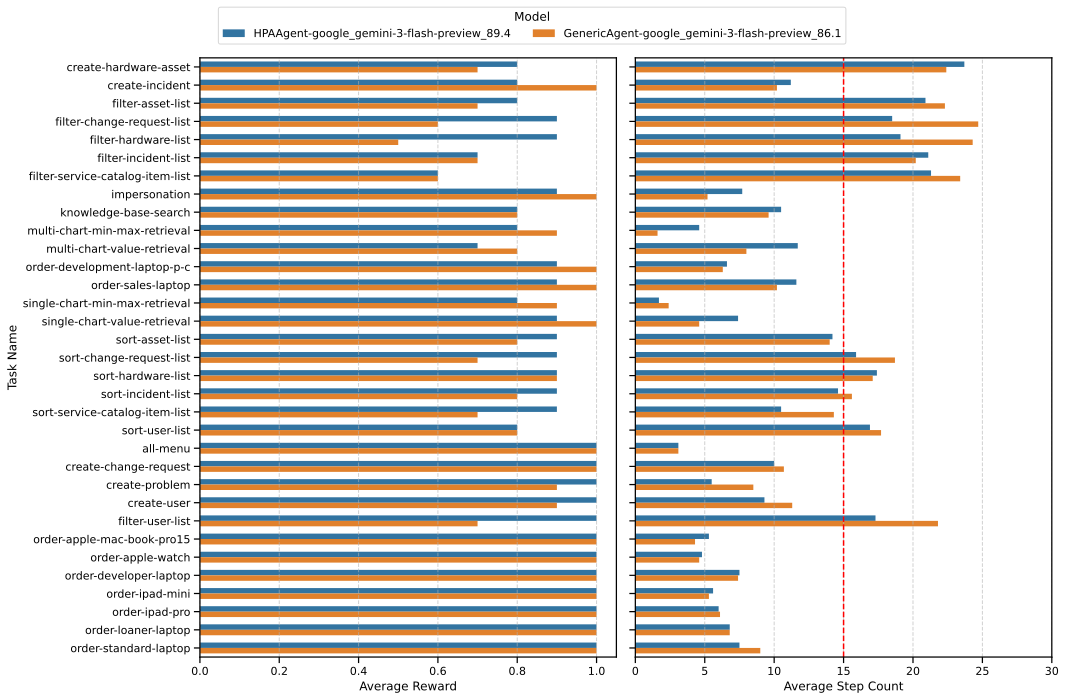

In [16]:
plot_combined_reward_step_count(preprocessed_concat)

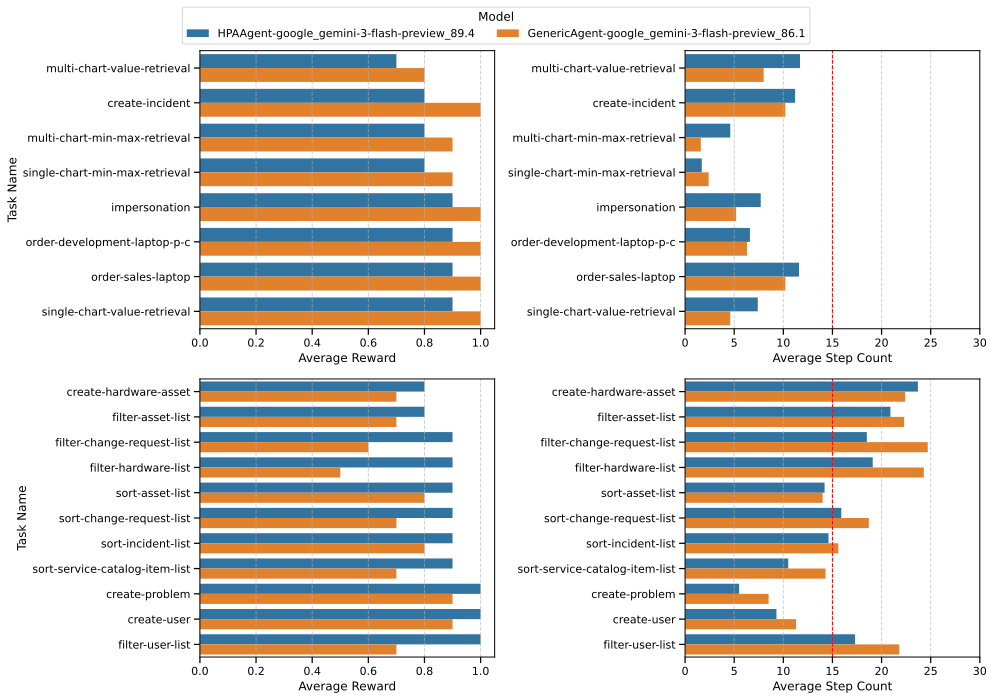

In [17]:
plot_combined_reward_step_count_filtered(df_list=[aggregated_baseline, aggregated_hpa])

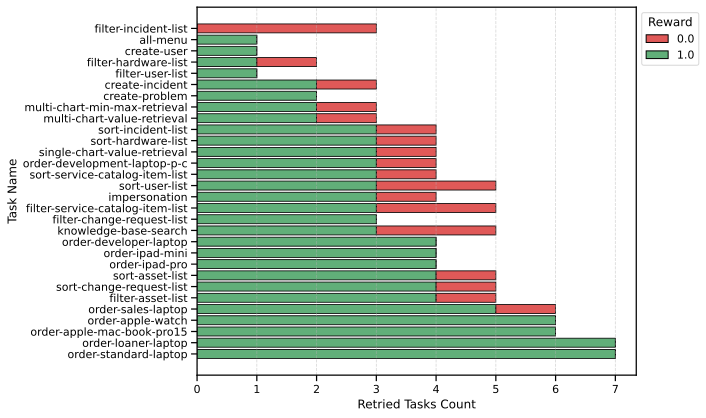

In [18]:
visualize_retried_tasks(df=preprocessed_hpa, save=True)

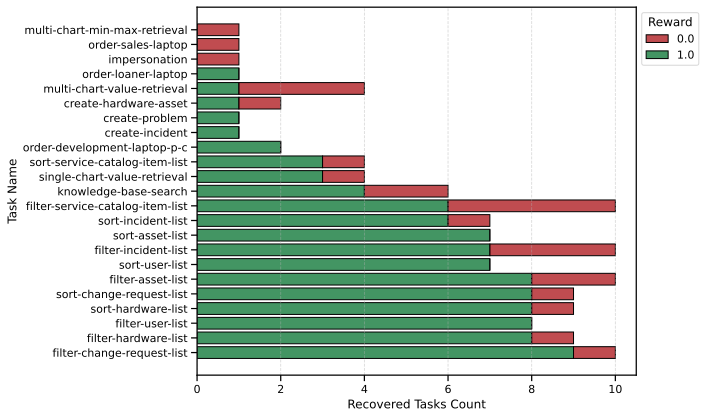

In [19]:
visualize_recovered_tasks(df=preprocessed_hpa)

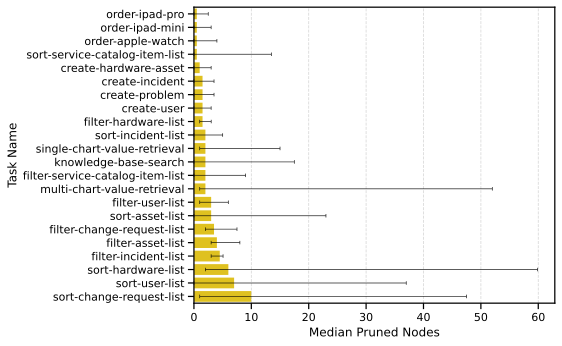

In [20]:
visualize_pruned_tasks(df=preprocessed_hpa)

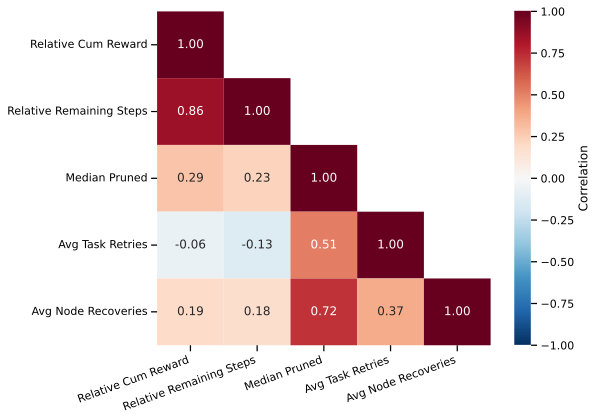

In [21]:
plot_correlation(df=aggregated_hpa, is_genericagent=False, relative_to_baseline=True)

In [124]:
# preprocessed_hpa.iloc[140]["tree_evolution"]["step_1"]["action_verification"]

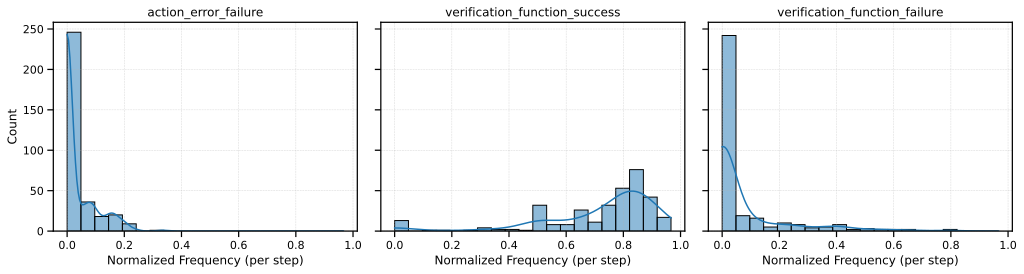

In [ ]:
# 1. Expand the column of dictionaries into separate columns
df_stats = pd.DataFrame(preprocessed_hpa['action_verifications'].tolist())
df_stats = df_stats.drop(columns=['action_error_success', 'no_verification', 'first_step'])

# 2. Melt the dataframe into "Long Format"
df_melted = df_stats.melt(var_name='Verification Type', value_name='Value')

# 3. Plot the distributions' histograms with Kernel Density Estimates (KDE)
g = sns.displot(
    data=df_melted, 
    x="Value", 
    col="Verification Type", 
    col_wrap=3,      # New row after 3 plots
    kind="hist",     # Change this to "kde" for just the curves
    kde=True,        # Adds the density curve over the histogram
    facet_kws={'sharey': True},
    height=4, 
    aspect=1.2,
    bins=20,
)

# Titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("Normalized Frequency", "Task Count")
plt.subplots_adjust(top=0.9)
# g.fig.suptitle('Distribution of Action Verification Metrics')

for ax in g.axes.flat:
    ax.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

plt.show()

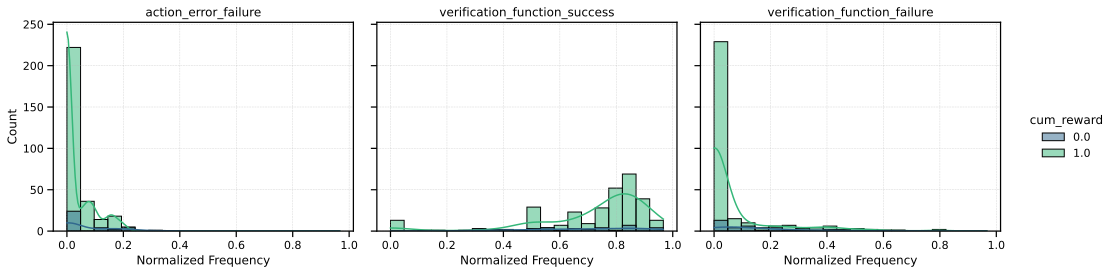

In [ ]:
# 1. Expand the dictionaries into a DataFrame
df_stats = pd.DataFrame(preprocessed_hpa['action_verifications'].tolist())
df_stats = df_stats.drop(columns=['action_error_success', 'no_verification', 'first_step'])

# 2. Add the cum_reward column to this new DataFrame
# We use .values to ensure alignment if indices have been reset
df_stats['cum_reward'] = preprocessed_hpa['cum_reward'].values

# 3. Melt the data, but keep 'cum_reward' as an identifier variable
df_melted = df_stats.melt(
    id_vars=['cum_reward'], 
    var_name='Verification Type', 
    value_name='Value'
)

# 4. Plot with hue="cum_reward"
g = sns.displot(
    data=df_melted, 
    x="Value", 
    hue="cum_reward",   # This creates the color grouping
    col="Verification Type", 
    col_wrap=3,
    kind="hist",         # Using KDE for clearer overlapping distributions
    kde=True,
    fill=True,          # Fills the area under the curve
    common_norm=False,  # Normalizes each hue group independently
    palette="viridis",  # Aesthetic color map
    facet_kws={'sharey': True},
    height=4, 
    aspect=1.2,
    bins=20,
)

# Cleanup
g.set_titles("{col_name}")
g.set_axis_labels("Normalized Frequency", "Task Count")
plt.subplots_adjust(top=0.9)
# g.fig.suptitle('Action Verification Distributions by Cumulative Reward')

for ax in g.axes.flat:
    ax.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    
plt.show()

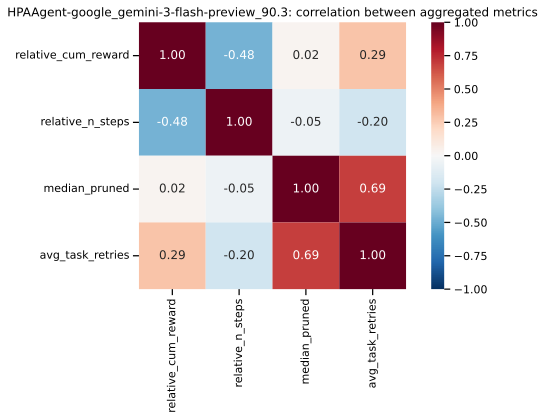

In [112]:
plot_correlation(df=aggregated_hpa, is_genericagent=False, relative_to_baseline=True)

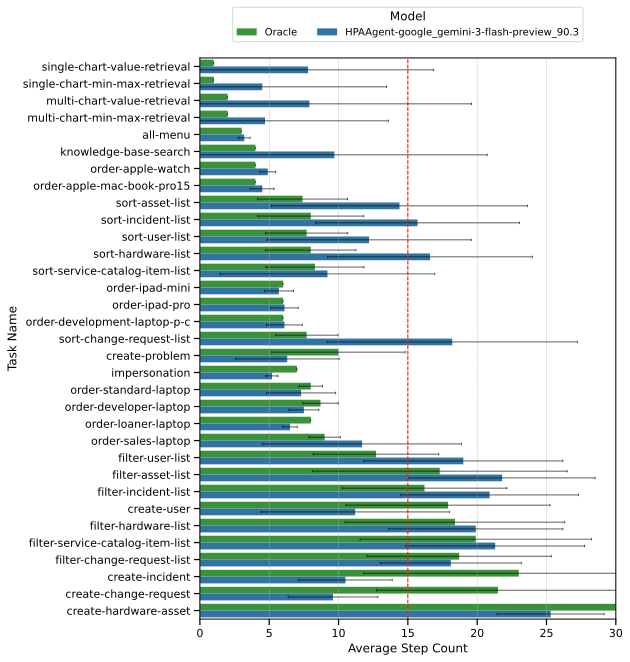

In [20]:
plot_average_step_count_vs_oracle(df=preprocessed_hpa)

# Run Tree Visualization

In [ ]:
#292, 261, 296
generate_tree_animation(data=preprocessed_hpa.iloc[261]["tree_evolution"], filename="tree_animation.gif", fps=0.5)

Generating frames for 15 steps...


Done! Animation saved as: tree_animation.gif


# Tests

In [113]:
# preprocessed_hpa[(preprocessed_hpa["pruned_nodes"] > 0) & (preprocessed_hpa["task_retries"] > 0) & (preprocessed_hpa["cum_reward"] > 0)].sort_values(by="n_steps", ascending=True).iloc[40:50]

In [ ]:
# import rich

# rich.print(preprocessed_hpa.iloc[261]["tree_evolution"])

In [ ]:
# class TreeVisualizer:
#     def __init__(self, data):
#         self.data = data
#         self.steps = sorted(data.keys(), key=lambda x: int(x.split("_")[1]))
#         self.type_colors = {
#             "OR": "#EBF5FB",      # Light Blue
#             "AND": "#D6EAF8",     # Med Blue
#             "ACTION": "#85C1E9",  # Strong Blue
#             "UNKNOWN": "#F4F6F7", # Grey/White
#         }
#         self.status_colors = {
#             "SUCCESS": "#1E8449",   # Green
#             "VISITED": "#2E86C1",   # Blue
#             "UNVISITED": "#ABB2B9", # Grey
#             "PRUNED": "#CB4335",    # Red (for the step it is pruned)
#         }

#     def get_global_layout(self):
#         """Calculates fixed positions for every node ever seen."""
#         full_G = nx.DiGraph()
#         for step_name in self.steps:
#             snapshot = self.data[step_name].get("tree_snapshot", [])
#             for node in snapshot:
#                 full_G.add_node(node["id"])
#                 if node.get("parent_id"):
#                     full_G.add_edge(node["parent_id"], node["id"])
        
#         # Use Pydot/Dot for hierarchical layout calculation
#         pydot_graph = nx.drawing.nx_pydot.to_pydot(full_G)
#         pydot_graph.set_rankdir("LR")
#         layout_dot = pydot_graph.create_dot(prog="dot").decode("utf-8")
#         positioned_graphs = pydot.graph_from_dot_data(layout_dot)
        
#         fixed_pos = {}
#         if positioned_graphs:
#             for node in positioned_graphs[0].get_nodes():
#                 name = node.get_name().strip('"')
#                 if name in ("graph", "node", "edge"): continue
#                 pos = node.get_pos()
#                 if pos:
#                     fixed_pos[name] = f"{pos.replace('"', '')}!"
#         return fixed_pos, list(full_G.nodes())

#     def create_frame(self, step_name, fixed_layout, all_node_ids):
#         step_data = self.data[step_name]
#         snapshot = step_data.get("tree_snapshot", [])
#         updates = step_data.get("tree_update", {})
#         pruned_ids = updates.get("prune", [])
        
#         # Determine retry count from expansions if available
#         retry_val = 0
#         if step_data.get("expansions"):
#             retry_val = step_data["expansions"][0].get("retry", 0)

#         dot = graphviz.Digraph(engine="neato", format="png")
#         dot.attr(overlap="false", splines="true", bgcolor="white", pad="0.5")
#         title = f"Step: {step_name.split('_')[1]} | Retry: {retry_val}\n{step_data['plan_steps']['current'][:60]}..."
#         dot.attr(label=title, labelloc="t", fontsize="20", fontname="Helvetica-Bold", fontcolor="#1B4F72")

#         current_node_map = {str(n["id"]): n for n in snapshot}
        
#         for nid in all_node_ids:
#             pos = fixed_layout.get(nid)
#             if not pos: continue

#             # If node is in current snapshot and NOT marked DELETED
#             if nid in current_node_map and current_node_map[nid]["status"] != "DELETED":
#                 node_data = current_node_map[nid]
#                 is_pruning = nid in pruned_ids
                
#                 # Styling Logic
#                 bg_color = self.type_colors.get(node_data["type"], "#FFFFFF")
#                 border_color = self.status_colors["PRUNED"] if is_pruning else self.status_colors.get(node_data["status"], "#BDC3C7")
#                 pen_width = "5" if is_pruning or node_data["status"] == "SUCCESS" else "2"
#                 style = "filled, rounded, dashed" if is_pruning else "filled, rounded"
                
#                 label = f"""<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0">
#                                <TR><TD><FONT POINT-SIZE="8" COLOR="#7F8C8D">{nid}</FONT></TD></TR>
#                                <TR><TD><B><FONT POINT-SIZE="11">{node_data['type']}</FONT></B></TD></TR>
#                                {f'<TR><TD><I><FONT POINT-SIZE="9" COLOR="red">PRUNED</FONT></I></TD></TR>' if is_pruning else ''}
#                             </TABLE>>"""

#                 dot.node(nid, label=label, pos=pos, style=style, fillcolor=bg_color, 
#                          color=border_color, penwidth=pen_width, shape="rect", fontname="Helvetica")
                
#                 # Draw edge if parent is also visible
#                 pid = str(node_data.get("parent_id"))
#                 if pid and pid in current_node_map and current_node_map[pid]["status"] != "DELETED":
#                     dot.edge(pid, nid, color="#ABB2B9", penwidth="1.5")
#             else:
#                 # Node is either deleted, pruned in a previous step, or from an inactive retry branch
#                 dot.node(nid, label="", pos=pos, style="invis")

#         return dot

# def generate_visual_evolution(data, output_gif="tree_evolution.gif", fps=1):
#     viz = TreeVisualizer(data)
#     fixed_layout, all_node_ids = viz.get_global_layout()
    
#     temp_folder = "frames"
#     os.makedirs(temp_folder, exist_ok=True)
    
#     frames = []
#     print("Processing steps...")
#     for i, step_name in enumerate(viz.steps):
#         gv = viz.create_frame(step_name, fixed_layout, all_node_ids)
#         path = os.path.join(temp_folder, f"frame_{i:03d}")
#         gv.render(path, cleanup=True)
        
#         img = Image.open(f"{path}.png").convert("RGB")
#         frames.append(np.array(img))

#     # Normalize frame sizes
#     max_h = max(f.shape[0] for f in frames)
#     max_w = max(f.shape[1] for f in frames)
    
#     final_frames = []
#     for f in frames:
#         new_im = Image.new("RGB", (max_w, max_h), (255, 255, 255))
#         new_im.paste(Image.fromarray(f), (0, 0))
#         final_frames.append(np.array(new_im))

#     imageio.mimsave(output_gif, final_frames, fps=fps, loop=0)
#     print(f"Animation saved to {output_gif}")

In [96]:
class TreeVisualizer:
    def __init__(self, data):
        self.data = data
        self.steps = sorted(data.keys(), key=lambda x: int(x.split("_")[1]))
        self.type_colors = {
            "OR": "#EBF5FB", "AND": "#D6EAF8", 
            "ACTION": "#85C1E9", "UNKNOWN": "#F4F6F7"
        }
        self.status_colors = {
            "SUCCESS": "#1E8449", "VISITED": "#2E86C1", 
            "UNVISITED": "#ABB2B9", "PRUNED": "#CB4335"
        }

    def get_global_layout(self):
        """Calculates fixed positions and bounding box for stability."""
        full_G = nx.DiGraph()
        for step_name in self.steps:
            snapshot = self.data[step_name].get("tree_snapshot", [])
            for node in snapshot:
                full_G.add_node(node["id"])
                if node.get("parent_id"):
                    full_G.add_edge(node["parent_id"], node["id"])
        
        pydot_graph = nx.drawing.nx_pydot.to_pydot(full_G)
        pydot_graph.set_rankdir("LR")
        layout_dot = pydot_graph.create_dot(prog="dot").decode("utf-8")
        positioned_graphs = pydot.graph_from_dot_data(layout_dot)
        
        fixed_pos = {}
        coords = []
        if positioned_graphs:
            for node in positioned_graphs[0].get_nodes():
                name = node.get_name().strip('"')
                if name in ("graph", "node", "edge"): continue
                pos = node.get_pos()
                if pos:
                    clean_pos = pos.replace('"', '')
                    fixed_pos[name] = f"{clean_pos}!"
                    coords.append([float(x) for x in clean_pos.split(',')])

        coords = np.array(coords)
        anchors = {}
        if len(coords) > 0:
            min_x, min_y = coords.min(axis=0)
            max_x, max_y = coords.max(axis=0)
            anchors = {
                "top_left": f"{min_x-50},{max_y+50}!",
                "bottom_right": f"{max_x+50},{min_y-50}!"
            }
        return fixed_pos, list(full_G.nodes()), anchors

    def create_frame(self, step_name, fixed_layout, all_node_ids, anchors):
        step_data = self.data[step_name]
        snapshot = step_data.get("tree_snapshot", [])
        updates = step_data.get("tree_update", {})
        pruned_ids = updates.get("prune", [])
        
        retry_val = 0
        if step_data.get("expansions"):
            retry_val = step_data["expansions"][0].get("retry", 0)

        # Using neato and splines=line for maximum arrow stability
        dot = graphviz.Digraph(engine="neato", format="png")
        dot.attr(overlap="false", splines="line", bgcolor="white", pad="0.5")
        
        # Lock viewport scale
        for aid, apos in anchors.items():
            dot.node(aid, label="", pos=apos, style="invis")

        # TITLE LOGIC: Sanitize and format
        step_info = f"Step: {step_name.split('_')[1]} | Retry: {retry_val}"
        
        # ESCAPE the action text to prevent "<node_expansion>" from being treated as an HTML tag
        raw_action = step_data['plan_steps']['current']
        safe_action = html.escape(raw_action[:80]) 
        
        title_html = (
            f'<<FONT FACE="Helvetica-Bold" POINT-SIZE="18">{step_info}</FONT>'
            f'<BR/>'
            f'<FONT FACE="Helvetica" POINT-SIZE="11">{safe_action}...</FONT>>'
        )
        
        dot.attr(label=title_html, labelloc="t", fontcolor="#1B4F72")

        current_node_map = {str(n["id"]): n for n in snapshot}
        
        for nid in all_node_ids:
            pos = fixed_layout.get(nid)
            if not pos: continue

            if nid in current_node_map and current_node_map[nid]["status"] != "DELETED":
                node_data = current_node_map[nid]
                is_pruning = nid in pruned_ids
                
                bg_color = self.type_colors.get(node_data["type"], "#FFFFFF")
                border_color = self.status_colors["PRUNED"] if is_pruning else self.status_colors.get(node_data["status"], "#BDC3C7")
                pen_width = "5" if is_pruning or node_data["status"] == "SUCCESS" else "2"
                style = "filled, rounded, dashed" if is_pruning else "filled, rounded"
                
                label = f"""<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0">
                               <TR><TD><FONT POINT-SIZE="8" COLOR="#7F8C8D">{nid}</FONT></TD></TR>
                               <TR><TD><B><FONT POINT-SIZE="11">{node_data['type']}</FONT></B></TD></TR>
                               {f'<TR><TD><I><FONT POINT-SIZE="9" COLOR="red">PRUNED</FONT></I></TD></TR>' if is_pruning else ''}
                            </TABLE>>"""

                dot.node(nid, label=label, pos=pos, style=style, fillcolor=bg_color, 
                         color=border_color, penwidth=pen_width, shape="rect", fontname="Helvetica")
                
                pid = str(node_data.get("parent_id"))
                if pid and pid in current_node_map and current_node_map[pid]["status"] != "DELETED":
                    dot.edge(pid, nid, color="#ABB2B9", penwidth="1.5", arrowhead="vee")
            else:
                dot.node(nid, label="", pos=pos, style="invis")

        return dot

def generate_visual_evolution(data, output_gif="tree_evolution.gif", fps=1):
    viz = TreeVisualizer(data)
    fixed_layout, all_node_ids, anchors = viz.get_global_layout()
    
    temp_folder = "frames"
    if not os.path.exists(temp_folder):
        os.makedirs(temp_folder)
    
    frames = []
    print(f"Processing steps at {fps} FPS...")
    for i, step_name in enumerate(viz.steps):
        gv = viz.create_frame(step_name, fixed_layout, all_node_ids, anchors)
        path = os.path.join(temp_folder, f"frame_{i:03d}")
        gv.render(path, cleanup=True)
        
        img = Image.open(f"{path}.png").convert("RGB")
        frames.append(np.array(img))

    max_h = max(f.shape[0] for f in frames)
    max_w = max(f.shape[1] for f in frames)
    
    final_frames = []
    for f in frames:
        new_im = Image.new("RGB", (max_w, max_h), (255, 255, 255))
        new_im.paste(Image.fromarray(f), (0, 0))
        final_frames.append(np.array(new_im))

    imageio.mimsave(output_gif, final_frames, fps=fps, loop=0)
    print(f"Animation saved to {output_gif}")
    
    # Cleanup
    for f in os.listdir(temp_folder):
        os.remove(os.path.join(temp_folder, f))
    os.rmdir(temp_folder)

In [ ]:
#261, 296
generate_visual_evolution(data=preprocessed_hpa.iloc[261]["tree_evolution"], fps=0.5)

Processing steps at 0.5 FPS...
Animation saved to tree_evolution.gif
